# Basic Statistics
## Descriptive Analytics and Data Preprocessing on Sales & Discounts Dataset

**Dataset:** sales_data_with_discounts.csv  
**Objective:** Compute descriptive statistics, visualize distributions, standardize numerical columns, and encode categorical variables.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Load the Dataset

In [2]:
# Load CSV using pandas
df = pd.read_csv('sales_data_with_discounts.csv')

print('Dataset loaded successfully.')
print('Shape (rows, columns):', df.shape)
print()
print('Columns:', list(df.columns))
print()
df.head()

Dataset loaded successfully.
Shape (rows, columns): (450, 13)

Columns: ['Date', 'Day', 'SKU', 'City', 'Volume', 'BU', 'Brand', 'Model', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']



,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [3]:
# Dataset overview
print('Data Types and Non-Null Counts:')
print(df.info())
print()
print('Missing Values per Column:')
print(df.isnull().sum().to_string())

Data Types and Non-Null Counts:
<class 'pandas.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    str    
 1   Day                450 non-null    str    
 2   SKU                450 non-null    str    
 3   City               450 non-null    str    
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    str    
 6   Brand              450 non-null    str    
 7   Model              450 non-null    str    
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), str(7)
memory usage: 45.8 KB
None

Missing Values per Column:
Date                 0
Day                  0
SKU             

## 3. Descriptive Analytics for Numerical Columns

Numerical columns in this dataset:
- **Volume** — units sold
- **Avg Price** — average selling price per unit
- **Total Sales Value** — gross sales (Volume x Avg Price)
- **Discount Rate (%)** — percentage discount applied
- **Discount Amount** — total discount in currency
- **Net Sales Value** — sales after discount

In [4]:
# Identify numerical and categorical columns
num_cols = ['Volume', 'Avg Price', 'Total Sales Value',
            'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']

cat_cols = ['Day', 'BU', 'Brand']

print('Numerical Columns :', num_cols)
print('Categorical Columns:', cat_cols)

Numerical Columns : ['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']
Categorical Columns: ['Day', 'BU', 'Brand']


In [5]:
# Built-in describe for a quick overview
print('Overall Descriptive Statistics:')
df[num_cols].describe().round(2)

Overall Descriptive Statistics:


,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
count,450.00,450.00,450.00,450.00,450.00,450.00
mean,5.07,10453.43,33812.84,15.16,3346.50,30466.34
std,4.23,18079.90,50535.07,4.22,4509.90,46358.66
min,1.00,290.00,400.00,5.01,69.18,326.97
25%,3.00,465.00,2700.00,13.97,460.46,2202.21
50%,4.00,1450.00,5700.00,16.58,988.93,4677.79
75%,6.00,10100.00,53200.00,18.11,5316.50,47847.91
max,31.00,60100.00,196400.00,19.99,25738.02,179507.48


In [6]:
# Calculate Mean, Median, Mode and Standard Deviation for each numerical column
stats_dict = {
    'Mean'  : df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Mode'  : df[num_cols].mode().iloc[0],
    'Std Dev': df[num_cols].std()
}

stats_df = pd.DataFrame(stats_dict).round(2)
print('Descriptive Statistics Table:')
stats_df

Descriptive Statistics Table:


,Mean,Median,Mode,Std Dev
Volume,5.07,4.00,3.00,4.23
Avg Price,10453.43,1450.00,400.00,18079.90
Total Sales Value,33812.84,5700.00,24300.00,50535.07
Discount Rate (%),15.16,16.58,5.01,4.22
Discount Amount,3346.50,988.93,69.18,4509.90
Net Sales Value,30466.34,4677.79,326.97,46358.66


In [7]:
# Individual column statistics with interpretation
for col in num_cols:
    mean   = df[col].mean()
    median = df[col].median()
    mode   = df[col].mode().iloc[0]
    std    = df[col].std()
    skew   = 'right-skewed' if mean > median else ('left-skewed' if mean < median else 'symmetric')

    print(f'--- {col} ---')
    print(f'  Mean   : {mean:.2f}')
    print(f'  Median : {median:.2f}')
    print(f'  Mode   : {mode:.2f}')
    print(f'  Std Dev: {std:.2f}')
    print(f'  Distribution is {skew} (mean vs median comparison)')
    print()

--- Volume ---
  Mean   : 5.07
  Median : 4.00
  Mode   : 3.00
  Std Dev: 4.23
  Distribution is right-skewed (mean vs median comparison)

--- Avg Price ---
  Mean   : 10453.43
  Median : 1450.00
  Mode   : 400.00
  Std Dev: 18079.90
  Distribution is right-skewed (mean vs median comparison)

--- Total Sales Value ---
  Mean   : 33812.84
  Median : 5700.00
  Mode   : 24300.00
  Std Dev: 50535.07
  Distribution is right-skewed (mean vs median comparison)

--- Discount Rate (%) ---
  Mean   : 15.16
  Median : 16.58
  Mode   : 5.01
  Std Dev: 4.22
  Distribution is left-skewed (mean vs median comparison)

--- Discount Amount ---
  Mean   : 3346.50
  Median : 988.93
  Mode   : 69.18
  Std Dev: 4509.90
  Distribution is right-skewed (mean vs median comparison)

--- Net Sales Value ---
  Mean   : 30466.34
  Median : 4677.79
  Mode   : 326.97
  Std Dev: 46358.66
  Distribution is right-skewed (mean vs median comparison)



## 4. Data Visualization

### 4a. Histograms — Distribution of Numerical Columns

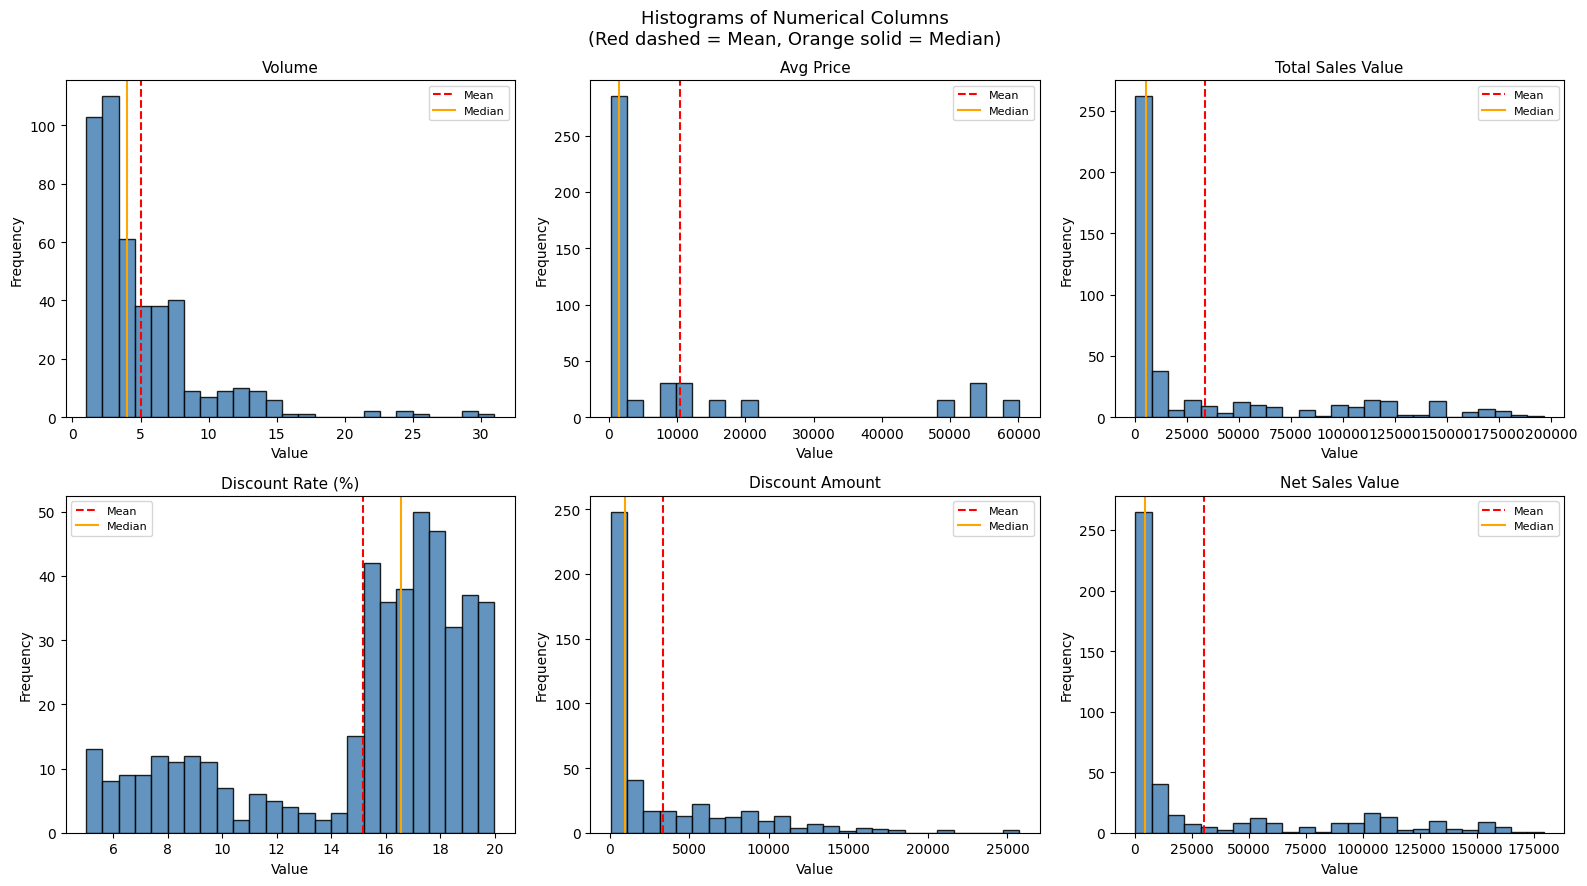

Inference:
  Volume           - Most sales are in low-volume transactions; right skew due to a few bulk orders.
  Avg Price        - Prices spread across wide range indicating multiple product categories.
  Total Sales Value- Right skewed; majority are small transactions with few high-value ones.
  Discount Rate (%)- Roughly bell-shaped; discounts mostly cluster around the average rate.
  Discount Amount  - Right skewed; higher discounts are rare.
  Net Sales Value  - Similar pattern to Total Sales Value, shifted down due to discounts.


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=25, color='steelblue', edgecolor='black', alpha=0.85)

    # Add mean and median vertical lines
    axes[i].axvline(df[col].mean(),   color='red',    linestyle='--', linewidth=1.5, label='Mean')
    axes[i].axvline(df[col].median(), color='orange', linestyle='-',  linewidth=1.5, label='Median')

    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)

plt.suptitle('Histograms of Numerical Columns\n(Red dashed = Mean, Orange solid = Median)',
             fontsize=13)
plt.tight_layout()
plt.show()

print('Inference:')
print('  Volume           - Most sales are in low-volume transactions; right skew due to a few bulk orders.')
print('  Avg Price        - Prices spread across wide range indicating multiple product categories.')
print('  Total Sales Value- Right skewed; majority are small transactions with few high-value ones.')
print('  Discount Rate (%)- Roughly bell-shaped; discounts mostly cluster around the average rate.')
print('  Discount Amount  - Right skewed; higher discounts are rare.')
print('  Net Sales Value  - Similar pattern to Total Sales Value, shifted down due to discounts.')

### 4b. Boxplots — Outlier Detection and IQR

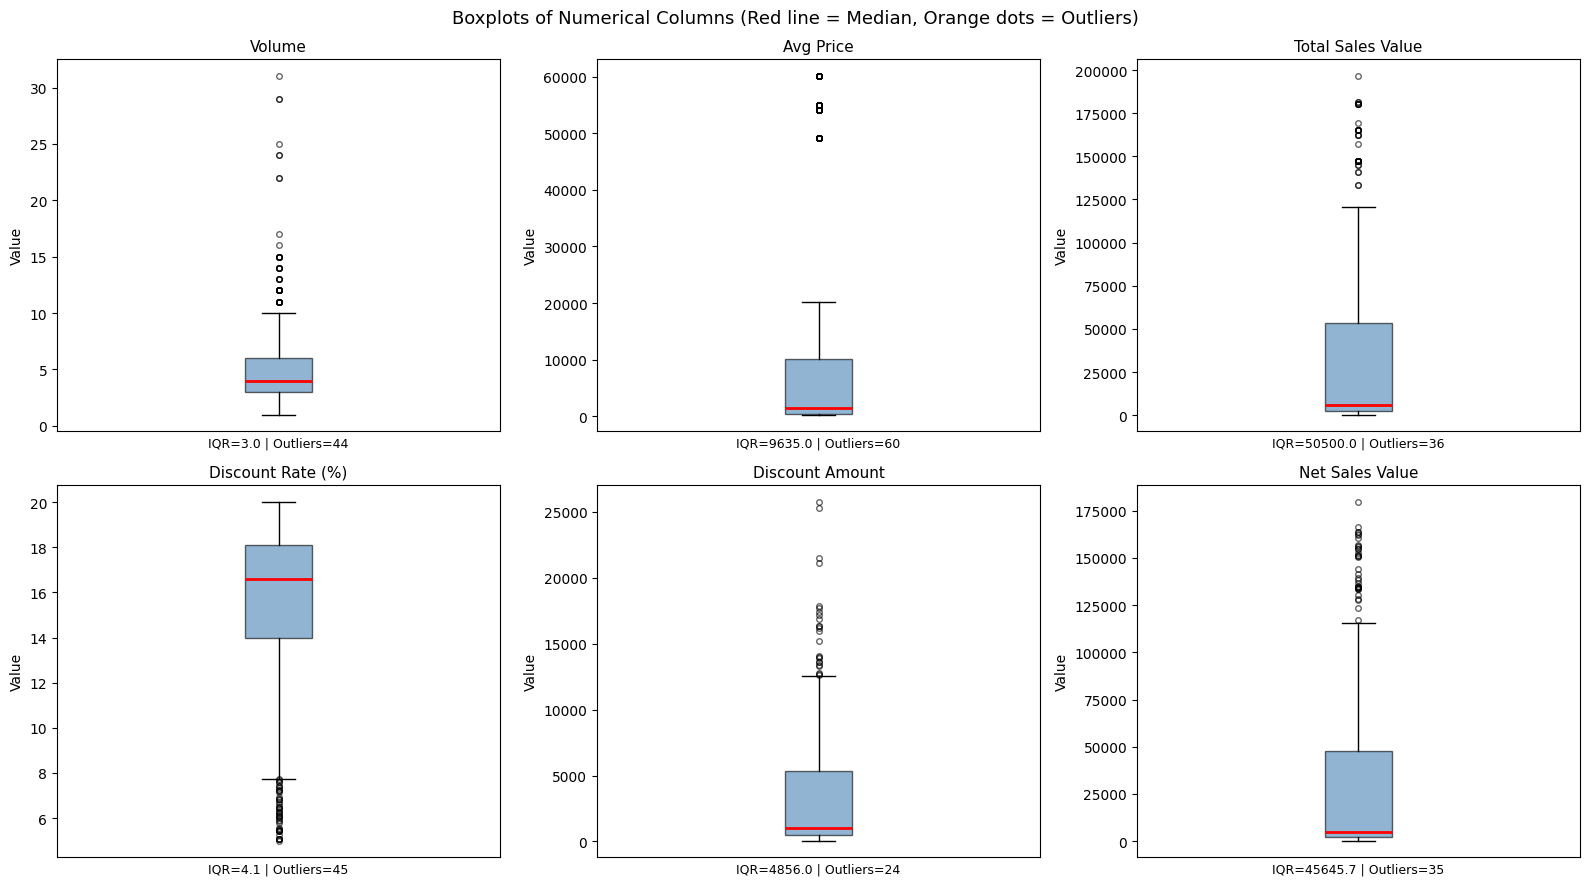

Boxplot Findings:
  Volume                    Q1=3.0  Q3=6.0  IQR=3.0  Outliers=44
  Avg Price                 Q1=465.0  Q3=10100.0  IQR=9635.0  Outliers=60
  Total Sales Value         Q1=2700.0  Q3=53200.0  IQR=50500.0  Outliers=36
  Discount Rate (%)         Q1=14.0  Q3=18.1  IQR=4.1  Outliers=45
  Discount Amount           Q1=460.5  Q3=5316.5  IQR=4856.0  Outliers=24
  Net Sales Value           Q1=2202.2  Q3=47847.9  IQR=45645.7  Outliers=35


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(
        df[col].dropna(),
        patch_artist=True,
        vert=True,
        boxprops=dict(facecolor='steelblue', alpha=0.6),
        medianprops=dict(color='red', linewidth=2),
        flierprops=dict(marker='o', color='orange', markersize=4, alpha=0.6)
    )
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Value')
    axes[i].set_xticks([])

    # Print IQR info
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    axes[i].set_xlabel(f'IQR={IQR:.1f} | Outliers={len(outliers)}', fontsize=9)

plt.suptitle('Boxplots of Numerical Columns (Red line = Median, Orange dots = Outliers)',
             fontsize=13)
plt.tight_layout()
plt.show()

print('Boxplot Findings:')
for col in num_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f'  {col:<25} Q1={Q1:.1f}  Q3={Q3:.1f}  IQR={IQR:.1f}  Outliers={len(outliers)}')

### 4c. Bar Charts — Categorical Columns

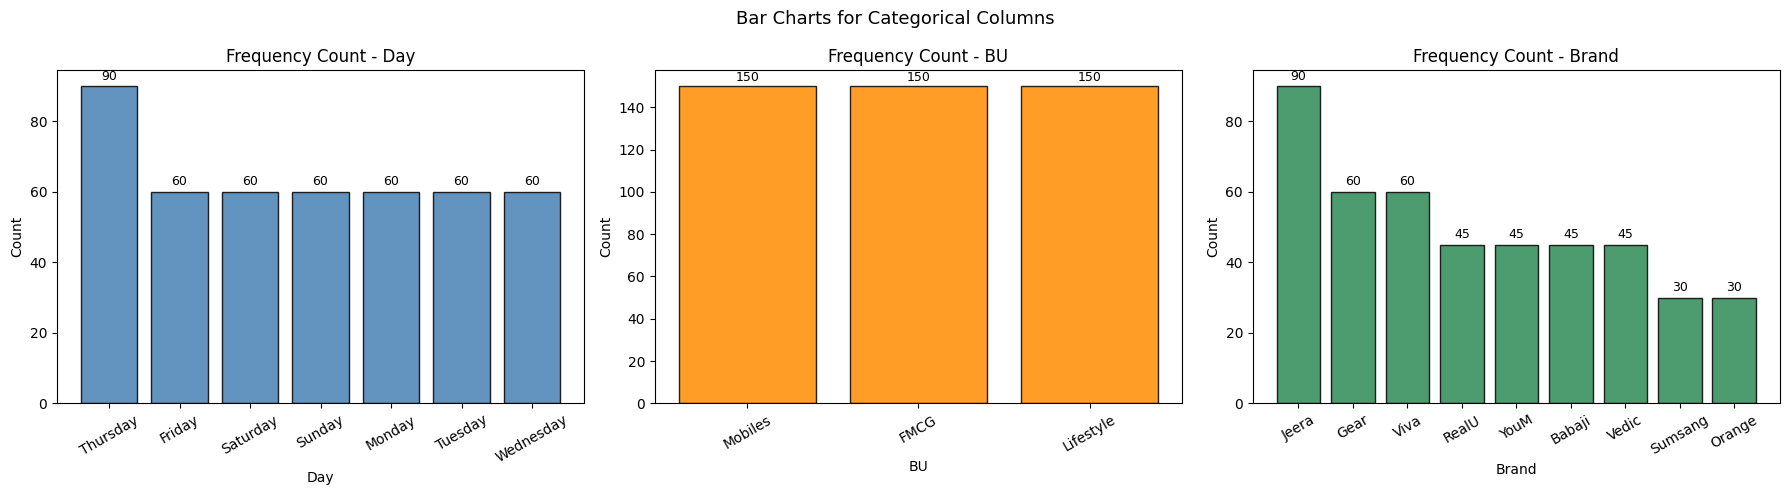

Bar Chart Insights:
  Day:
    Thursday        : 90 records (20.0%)
    Friday          : 60 records (13.3%)
    Saturday        : 60 records (13.3%)
    Sunday          : 60 records (13.3%)
    Monday          : 60 records (13.3%)
    Tuesday         : 60 records (13.3%)
    Wednesday       : 60 records (13.3%)

  BU:
    Mobiles         : 150 records (33.3%)
    FMCG            : 150 records (33.3%)
    Lifestyle       : 150 records (33.3%)

  Brand:
    Jeera           : 90 records (20.0%)
    Gear            : 60 records (13.3%)
    Viva            : 60 records (13.3%)
    RealU           : 45 records (10.0%)
    YouM            : 45 records (10.0%)
    Babaji          : 45 records (10.0%)
    Vedic           : 45 records (10.0%)
    Sumsang         : 30 records (6.7%)
    Orange          : 30 records (6.7%)



In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bar_colors = ['steelblue', 'darkorange', 'seagreen']

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts().sort_values(ascending=False)
    axes[i].bar(counts.index, counts.values,
                color=bar_colors[i], edgecolor='black', alpha=0.85)
    axes[i].set_title(f'Frequency Count - {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)

    # Add count labels on bars
    for bar_val, count in zip(axes[i].patches, counts.values):
        axes[i].text(
            bar_val.get_x() + bar_val.get_width() / 2,
            bar_val.get_height() + 1,
            str(count), ha='center', va='bottom', fontsize=9
        )

plt.suptitle('Bar Charts for Categorical Columns', fontsize=13)
plt.tight_layout()
plt.show()

print('Bar Chart Insights:')
for col in cat_cols:
    counts = df[col].value_counts()
    print(f'  {col}:')
    for cat, cnt in counts.items():
        print(f'    {cat:<15} : {cnt} records ({cnt/len(df)*100:.1f}%)')
    print()

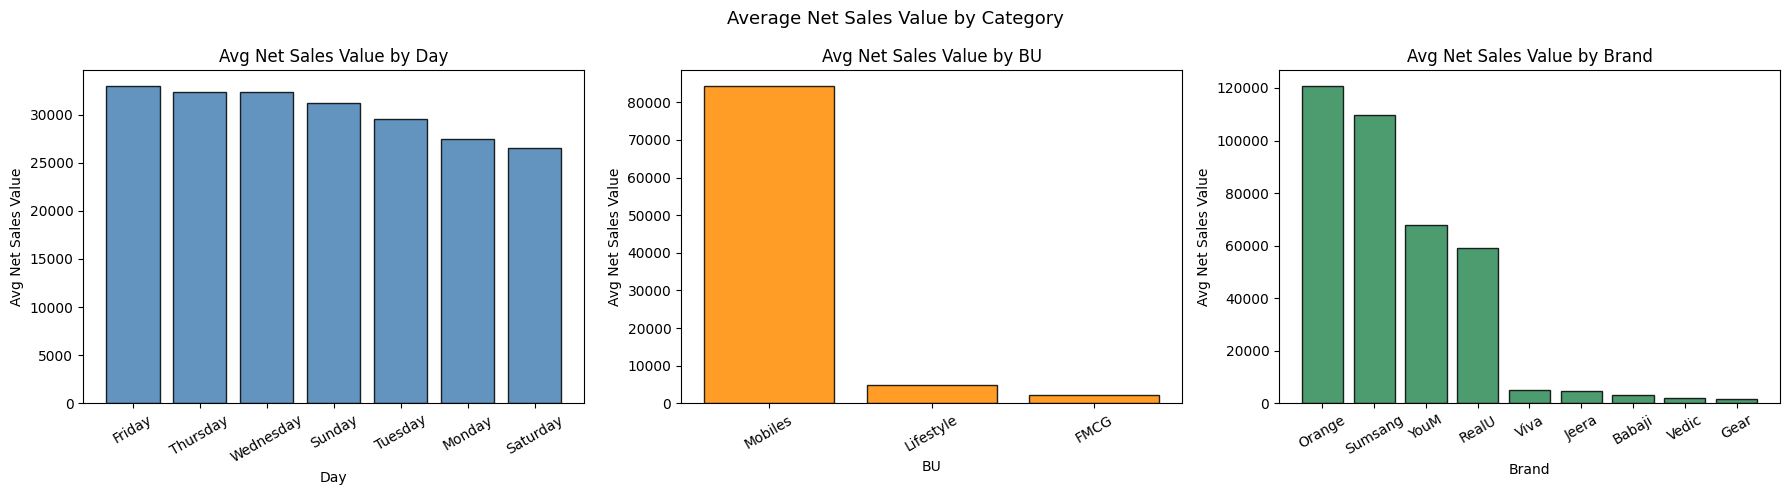

In [11]:
# Average Net Sales Value by each categorical column
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(cat_cols):
    avg_sales = df.groupby(col)['Net Sales Value'].mean().sort_values(ascending=False)
    axes[i].bar(avg_sales.index, avg_sales.values,
                color=bar_colors[i], edgecolor='black', alpha=0.85)
    axes[i].set_title(f'Avg Net Sales Value by {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Avg Net Sales Value')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Average Net Sales Value by Category', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Standardization of Numerical Variables

**What is Standardization (Z-score Normalization)?**

Standardization transforms each value so that the resulting distribution has a **mean of 0** and a **standard deviation of 1**.

**Formula:**

    z = (x - mean) / std_dev

**Why it is needed:**
- Clustering, regression, and other distance-based algorithms are sensitive to the scale of features.
- A column with values in the millions (e.g., Net Sales Value) would dominate one with values in tens (e.g., Volume) without scaling.
- Standardization puts all features on a common scale without distorting differences.

In [12]:
# Standardize numerical columns using pandas (manual z-score, no sklearn)
df_standardized = df.copy()

for col in num_cols:
    col_mean = df[col].mean()
    col_std  = df[col].std()
    df_standardized[col] = (df[col] - col_mean) / col_std

print('Before Standardization - Mean and Std Dev:')
print(df[num_cols].agg(['mean', 'std']).round(4).to_string())
print()
print('After Standardization - Mean and Std Dev (should be ~0 and ~1):')
print(df_standardized[num_cols].agg(['mean', 'std']).round(4).to_string())

Before Standardization - Mean and Std Dev:
      Volume   Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  Net Sales Value
mean  5.0667  10453.4333         33812.8356            15.1552        3346.4994       30466.3361
std   4.2316  18079.9048         50535.0742             4.2206        4509.9030       46358.6566

After Standardization - Mean and Std Dev (should be ~0 and ~1):
      Volume  Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  Net Sales Value
mean     0.0        0.0                0.0               -0.0             -0.0              0.0
std      1.0        1.0                1.0                1.0              1.0              1.0


In [13]:
# Before vs After comparison (first 5 rows)
print('Before Standardization (first 5 rows):')
display(df[num_cols].head())

print('After Standardization (first 5 rows):')
display(df_standardized[num_cols].round(4).head())

Before Standardization (first 5 rows):


,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,15,12100,181500,11.654820,21153.498820,160346.501180
1,10,10100,101000,11.560498,11676.102961,89323.897039
2,7,16100,112700,9.456886,10657.910157,102042.089843
3,6,20100,120600,6.935385,8364.074702,112235.925298
4,3,8100,24300,17.995663,4372.946230,19927.053770


After Standardization (first 5 rows):


,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,2.3474,0.0911,2.9225,-0.8294,3.9484,2.8016
1,1.1658,-0.0195,1.3295,-0.8517,1.8470,1.2696
2,0.4569,0.3123,1.5610,-1.3501,1.6212,1.5440
3,0.2206,0.5336,1.7174,-1.9476,1.1126,1.7638
4,-0.4884,-0.1302,-0.1882,0.6730,0.2276,-0.2273


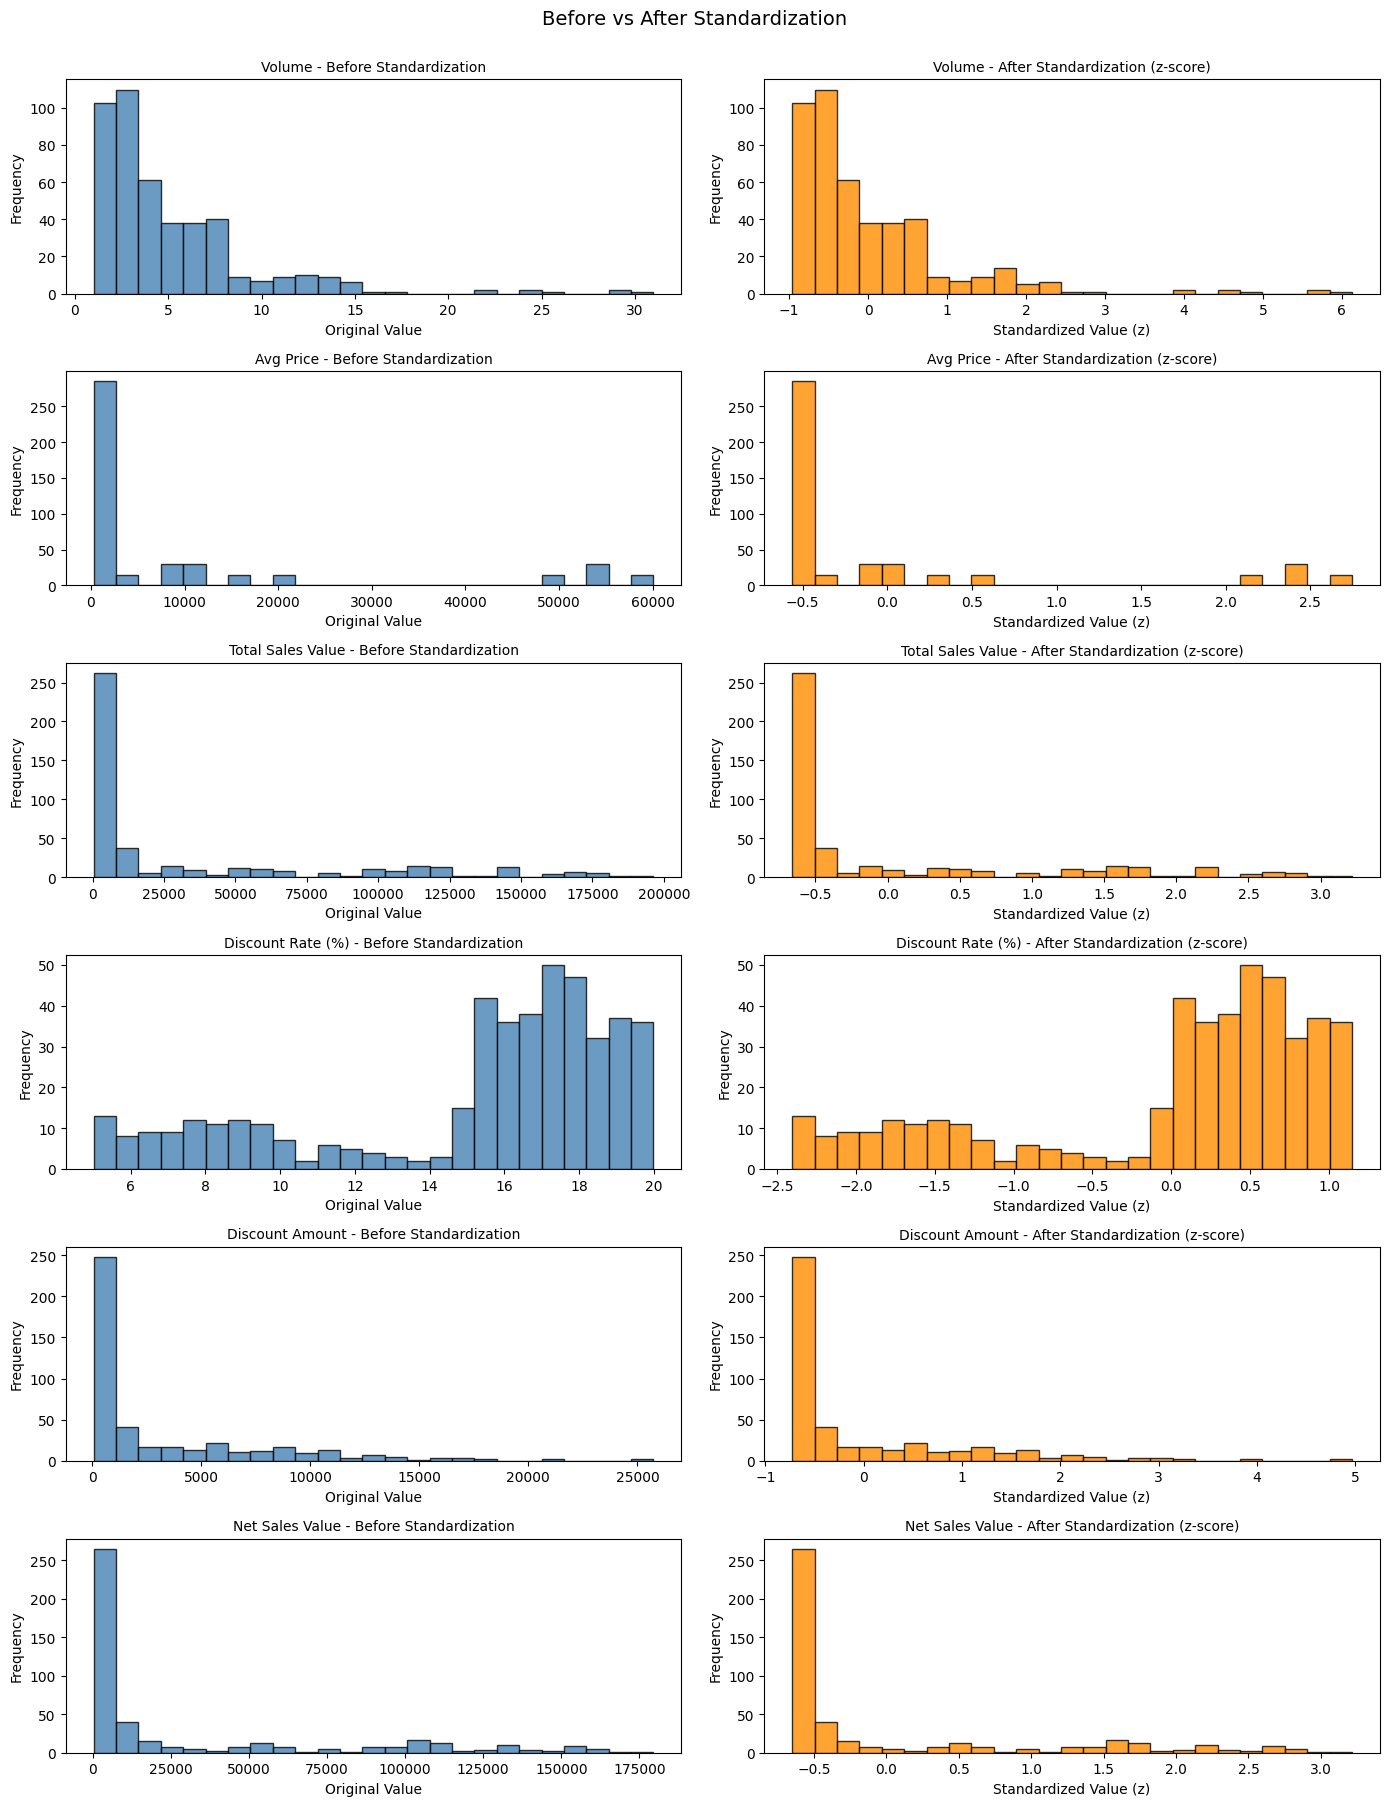

Observation: The shape of the distribution stays the same after standardization.
Only the scale changes - all columns now centered at 0 with unit standard deviation.


In [14]:
# Before vs After distribution comparison
fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, 18))

for i, col in enumerate(num_cols):
    # Before
    axes[i][0].hist(df[col], bins=25, color='steelblue', edgecolor='black', alpha=0.8)
    axes[i][0].set_title(f'{col} - Before Standardization', fontsize=10)
    axes[i][0].set_xlabel('Original Value')
    axes[i][0].set_ylabel('Frequency')

    # After
    axes[i][1].hist(df_standardized[col], bins=25, color='darkorange', edgecolor='black', alpha=0.8)
    axes[i][1].set_title(f'{col} - After Standardization (z-score)', fontsize=10)
    axes[i][1].set_xlabel('Standardized Value (z)')
    axes[i][1].set_ylabel('Frequency')

plt.suptitle('Before vs After Standardization', fontsize=14, y=1.001)
plt.tight_layout()
plt.show()

print('Observation: The shape of the distribution stays the same after standardization.')
print('Only the scale changes - all columns now centered at 0 with unit standard deviation.')

## 6. Conversion of Categorical Data into Dummy Variables (One-Hot Encoding)

**Why One-Hot Encoding?**

Machine learning algorithms work with numbers, not text. Categorical columns like `Day`, `BU`, and `Brand` need to be converted into numerical format.

One-Hot Encoding creates a new binary column (0 or 1) for each unique category:
- 1 = the record belongs to that category
- 0 = it does not

This avoids implying any order or rank between categories (which label encoding would do).

In [15]:
# One-Hot Encoding using pandas get_dummies
# drop_first=True removes one dummy per category to avoid multicollinearity (dummy variable trap)

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=False)

print('Shape before encoding:', df.shape)
print('Shape after encoding :', df_encoded.shape)
print()
print('New dummy columns created:')
new_cols = [c for c in df_encoded.columns if c not in df.columns]
print(new_cols)

Shape before encoding: (450, 13)
Shape after encoding : (450, 29)

New dummy columns created:
['Day_Friday', 'Day_Monday', 'Day_Saturday', 'Day_Sunday', 'Day_Thursday', 'Day_Tuesday', 'Day_Wednesday', 'BU_FMCG', 'BU_Lifestyle', 'BU_Mobiles', 'Brand_Babaji', 'Brand_Gear', 'Brand_Jeera', 'Brand_Orange', 'Brand_RealU', 'Brand_Sumsang', 'Brand_Vedic', 'Brand_Viva', 'Brand_YouM']


In [16]:
# Show original vs encoded side by side for first 5 rows
print('Original Categorical Columns (first 5 rows):')
display(df[['Day', 'BU', 'Brand']].head())

print('After One-Hot Encoding (dummy columns only, first 5 rows):')
display(df_encoded[new_cols].head())

Original Categorical Columns (first 5 rows):


,Day,BU,Brand
0,Thursday,Mobiles,RealU
1,Thursday,Mobiles,RealU
2,Thursday,Mobiles,YouM
3,Thursday,Mobiles,YouM
4,Thursday,Mobiles,YouM


After One-Hot Encoding (dummy columns only, first 5 rows):


,Day_Friday,Day_Monday,Day_Saturday,Day_Sunday,Day_Thursday,Day_Tuesday,Day_Wednesday,BU_FMCG,BU_Lifestyle,BU_Mobiles,Brand_Babaji,Brand_Gear,Brand_Jeera,Brand_Orange,Brand_RealU,Brand_Sumsang,Brand_Vedic,Brand_Viva,Brand_YouM
0,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False
1,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False
2,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True
3,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True
4,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True


In [17]:
# Full encoded dataset (all columns)
print('Final Encoded Dataset (first 5 rows):')
df_encoded.head()

Final Encoded Dataset (first 5 rows):


,Date,SKU,City,Volume,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value,...,BU_Mobiles,Brand_Babaji,Brand_Gear,Brand_Jeera,Brand_Orange,Brand_RealU,Brand_Sumsang,Brand_Vedic,Brand_Viva,Brand_YouM
0,01-04-2021,M01,C,15,RU-10,12100,181500,11.654820,21153.498820,160346.501180,...,True,False,False,False,False,True,False,False,False,False
1,01-04-2021,M02,C,10,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039,...,True,False,False,False,False,True,False,False,False,False
2,01-04-2021,M03,C,7,YM-99,16100,112700,9.456886,10657.910157,102042.089843,...,True,False,False,False,False,False,False,False,False,True
3,01-04-2021,M04,C,6,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298,...,True,False,False,False,False,False,False,False,False,True
4,01-04-2021,M05,C,3,YM-98,8100,24300,17.995663,4372.946230,19927.053770,...,True,False,False,False,False,False,False,False,False,True


In [18]:
# Verify dummy variable correctness
print('Verification - Sum of Day dummies per row (should all be 1):')
day_cols = [c for c in df_encoded.columns if c.startswith('Day_')]
print(df_encoded[day_cols].sum(axis=1).value_counts().to_string())
print()
print('Verification - Sum of BU dummies per row (should all be 1):')
bu_cols = [c for c in df_encoded.columns if c.startswith('BU_')]
print(df_encoded[bu_cols].sum(axis=1).value_counts().to_string())

Verification - Sum of Day dummies per row (should all be 1):
1    450

Verification - Sum of BU dummies per row (should all be 1):
1    450


## 7. Conclusion

In [19]:
print('KEY FINDINGS SUMMARY')
print('=' * 60)
print()
print('1. Descriptive Analytics')
print('   - Dataset has 450 records and 13 columns with no missing values.')
print('   - Numerical columns like Total Sales Value and Net Sales Value')
print('     are right-skewed, indicating most transactions are small with')
print('     a few high-value outliers.')
print('   - Discount Rate (%) is relatively symmetric around its mean.')
print()
print('2. Data Visualization')
print('   - Histograms confirmed right skew in sales-related columns.')
print('   - Boxplots revealed outliers in Volume, Total Sales Value,')
print('     and Net Sales Value - these are high-volume bulk transactions.')
print('   - Bar charts showed all 7 days are represented in the dataset.')
print('     BU has 3 business units and Brand has 9 unique brands.')
print()
print('3. Standardization')
print('   - Z-score normalization successfully scaled all numerical columns')
print('     to mean=0 and std=1.')
print('   - The shape of each distribution is preserved - only the scale changes.')
print('   - Essential for distance-based ML algorithms like KNN and K-Means.')
print()
print('4. One-Hot Encoding')
print('   - Day (7 categories), BU (3 categories), Brand (9 categories)')
print('     were successfully encoded into binary dummy columns.')
print('   - Dataset expanded from 13 columns to', df_encoded.shape[1], 'columns.')
print('   - This format is now ready to be used as input for ML models.')

KEY FINDINGS SUMMARY

1. Descriptive Analytics
   - Dataset has 450 records and 13 columns with no missing values.
   - Numerical columns like Total Sales Value and Net Sales Value
     are right-skewed, indicating most transactions are small with
     a few high-value outliers.
   - Discount Rate (%) is relatively symmetric around its mean.

2. Data Visualization
   - Histograms confirmed right skew in sales-related columns.
   - Boxplots revealed outliers in Volume, Total Sales Value,
     and Net Sales Value - these are high-volume bulk transactions.
   - Bar charts showed all 7 days are represented in the dataset.
     BU has 3 business units and Brand has 9 unique brands.

3. Standardization
   - Z-score normalization successfully scaled all numerical columns
     to mean=0 and std=1.
   - The shape of each distribution is preserved - only the scale changes.
   - Essential for distance-based ML algorithms like KNN and K-Means.

4. One-Hot Encoding
   - Day (7 categories), BU (3 ca